**STEP 1: IMPORTS + DATA LOADING**

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

**STEP 2: LOAD DATASET**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/BITS PILANI Assignments/hotel_bookings.csv.zip")

# Preview
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


**STEP 3: BASIC CHECKS**

In [4]:
# Shape
print("Shape:", df.shape)

# Info
df.info()

# Missing values
df.isnull().sum()

# Target distribution
df['is_canceled'].value_counts()

Shape: (119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 

,count
is_canceled,
0,75166
1,44224


**STEP 4: FEATURE & TARGET SPLIT**

In [5]:
# Target
y = df['is_canceled']

# Drop leakage columns
X = df.drop(columns=[
    'is_canceled',
    'reservation_status',
    'reservation_status_date'
])

**STEP 5: IDENTIFY COLUMN TYPES**

In [6]:
# Numeric & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')
Categorical: Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='object')


**STEP 6: TRAIN-TEST SPLIT**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**STEP 7: BASELINE PREPROCESSING**

In [8]:
# Numeric pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

**STEP 8: BASELINE MODEL**

In [9]:
# Full pipeline
baseline_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# Train
baseline_model.fit(X_train, y_train)

# Predict
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

**STEP 9: EVALUATION**

Accuracy: 0.8172795041460759
ROC-AUC: 0.8927152049925815


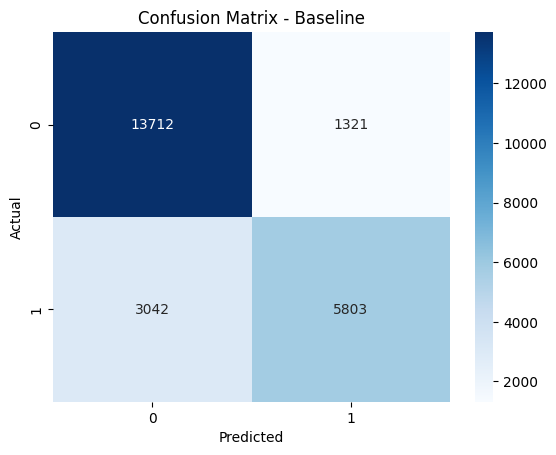

Model performance is strong


In [10]:
# Accuracy
acc = accuracy_score(y_test, y_pred)

# ROC-AUC
roc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("ROC-AUC:", roc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline")
plt.show()

# Report
if roc > 0.8:
    print("Model performance is strong")
elif roc > 0.7:
    print("Model performance is acceptable")
else:
    print("Model needs improvement")

**STEP 10: CURSE OF DIMENSIONALITY**

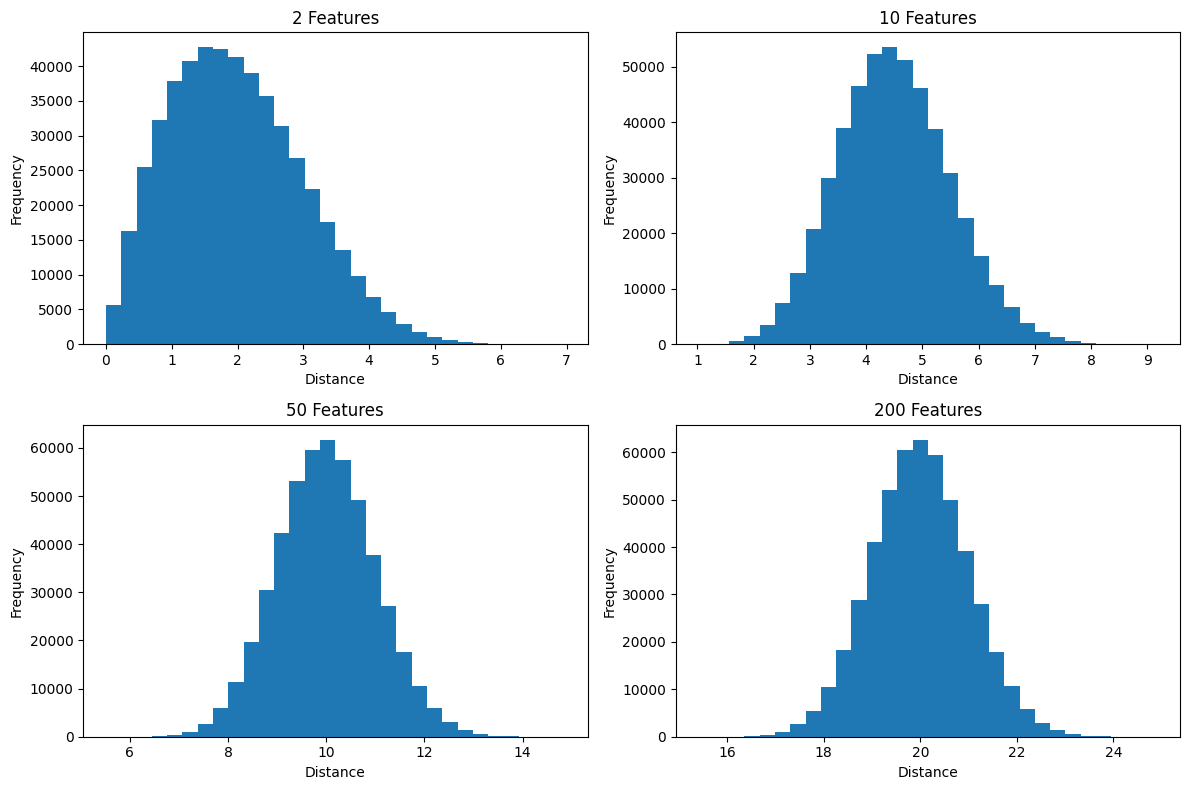

In [11]:
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist

dimensions = [2, 10, 50, 200]

plt.figure(figsize=(12,8))

for i, dim in enumerate(dimensions):
    X_syn, _ = make_classification(
        n_samples=1000,
        n_features=dim,
        n_informative=1, # Ensured n_informative is less than n_features
        n_redundant=0,   # Explicitly setting to ensure sum is minimal
        n_repeated=0,    # Explicitly setting to ensure sum is minimal
        n_clusters_per_class=1, # Fix: Ensure n_classes * n_clusters_per_class <= 2**n_informative
        random_state=42
    )

    # Compute pairwise distances
    distances = pdist(X_syn, metric='euclidean')

    plt.subplot(2, 2, i+1)
    plt.hist(distances, bins=30)
    plt.title(f"{dim} Features")
    plt.xlabel("Distance")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**STEP 11: SELECT NUMERIC FEATURES**

In [12]:
num_cols_selected = [
    'lead_time',
    'adr',
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    'adults',
    'children'
]

df_num = df[num_cols_selected].copy()
df_num.head()

,lead_time,adr,stays_in_week_nights,stays_in_weekend_nights,adults,children
0,342,0.0,0,0,2,0.0
1,737,0.0,0,0,2,0.0
2,7,75.0,1,0,1,0.0
3,13,75.0,1,0,1,0.0
4,14,98.0,2,0,2,0.0


**STEP 12: BINNING**

In [13]:
# Binning lead_time
df_num['lead_time_bin'] = pd.cut(df_num['lead_time'], bins=3, labels=['Low', 'Medium', 'High'])

# Binning adr
df_num['adr_bin'] = pd.qcut(df_num['adr'], q=3, labels=['Cheap', 'Moderate', 'Expensive'])

**STEP 13: BINARIZATION**

In [14]:
# High value customer
df_num['high_value_customer'] = (df_num['adr'] > 100).astype(int)

**STEP 14: SCALING COMPARISON**

In [15]:
# Apply scalers
minmax = MinMaxScaler()
standard = StandardScaler()
robust = RobustScaler()

df_minmax = pd.DataFrame(minmax.fit_transform(df_num[num_cols_selected]), columns=num_cols_selected)
df_standard = pd.DataFrame(standard.fit_transform(df_num[num_cols_selected]), columns=num_cols_selected)
df_robust = pd.DataFrame(robust.fit_transform(df_num[num_cols_selected]), columns=num_cols_selected)

**STEP 15: VISUAL COMPARISON**

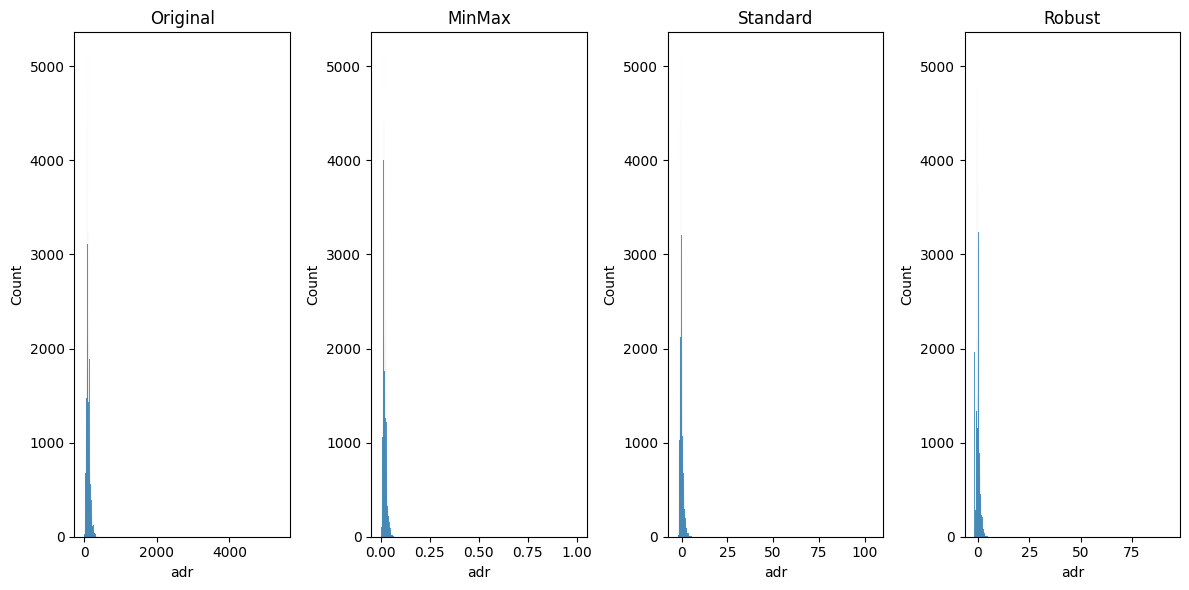

In [16]:
# Plot comparison for one feature (adr)
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
sns.histplot(df_num['adr'])
plt.title("Original")

plt.subplot(1,4,2)
sns.histplot(df_minmax['adr'])
plt.title("MinMax")

plt.subplot(1,4,3)
sns.histplot(df_standard['adr'])
plt.title("Standard")

plt.subplot(1,4,4)
sns.histplot(df_robust['adr'])
plt.title("Robust")

plt.tight_layout()
plt.show()

**STEP 16: SUMMARY STATS**

In [17]:
print("Original:\n", df_num[num_cols_selected].describe())
print("\nStandardScaler:\n", df_standard.describe())
print("\nRobustScaler:\n", df_robust.describe())

Original:
            lead_time            adr  stays_in_week_nights  \
count  119390.000000  119390.000000         119390.000000   
mean      104.011416     101.831122              2.500302   
std       106.863097      50.535790              1.908286   
min         0.000000      -6.380000              0.000000   
25%        18.000000      69.290000              1.000000   
50%        69.000000      94.575000              2.000000   
75%       160.000000     126.000000              3.000000   
max       737.000000    5400.000000             50.000000   

       stays_in_weekend_nights         adults       children  
count            119390.000000  119390.000000  119386.000000  
mean                  0.927599       1.856403       0.103890  
std                   0.998613       0.579261       0.398561  
min                   0.000000       0.000000       0.000000  
25%                   0.000000       2.000000       0.000000  
50%                   1.000000       2.000000       0.000000 

**STEP 17: PREPARE DATA FOR KNN**

In [18]:
X_knn = df[num_cols].fillna(df[num_cols].median())
y_knn = df['is_canceled']

from sklearn.model_selection import train_test_split

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn
)

**STEP 18: KNN WITHOUT SCALING**

In [19]:
# KNN without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train_knn, y_train_knn)

y_pred_no = knn_no_scale.predict(X_test_knn)

from sklearn.metrics import accuracy_score

acc_no = accuracy_score(y_test_knn, y_pred_no)
print("Accuracy without scaling:", acc_no)

Accuracy without scaling: 0.7766563363765809


**STEP 19: KNN WITH STANDARD SCALER**

In [20]:
# Apply StandardScaler
scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train_knn)
X_test_std = scaler_std.transform(X_test_knn)

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_train_std, y_train_knn)

y_pred_std = knn_std.predict(X_test_std)

acc_std = accuracy_score(y_test_knn, y_pred_std)
print("Accuracy with StandardScaler:", acc_std)

Accuracy with StandardScaler: 0.8079822430689337


**STEP 20: KNN WITH ROBUST SCALER**

In [21]:
# Apply RobustScaler
scaler_rob = RobustScaler()

X_train_rob = scaler_rob.fit_transform(X_train_knn)
X_test_rob = scaler_rob.transform(X_test_knn)

knn_rob = KNeighborsClassifier(n_neighbors=5)
knn_rob.fit(X_train_rob, y_train_knn)

y_pred_rob = knn_rob.predict(X_test_rob)

acc_rob = accuracy_score(y_test_knn, y_pred_rob)
print("Accuracy with RobustScaler:", acc_rob)

Accuracy with RobustScaler: 0.80869419549376


**STEP 21: DISTANCE METRIC COMPARISON**

In [38]:
# Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_std, y_train_knn)

y_pred_manhattan = knn_manhattan.predict(X_test_std)

acc_manhattan = accuracy_score(y_test_knn, y_pred_manhattan)
print("Accuracy with Manhattan distance:", acc_manhattan)

print("Accuracy without scaling:", acc_no)
print("Accuracy with StandardScaler:", acc_std)
print("Accuracy with RobustScaler:", acc_rob)
print("Accuracy with Manhattan distance:", acc_manhattan)

Accuracy with Manhattan distance: 0.8110813300946478
Accuracy without scaling: 0.7766563363765809
Accuracy with StandardScaler: 0.8079822430689337
Accuracy with RobustScaler: 0.80869419549376
Accuracy with Manhattan distance: 0.8110813300946478


**STEP 22: PIPELINE**

In [23]:
from sklearn.preprocessing import PowerTransformer

# Numeric pipeline with transformation
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson'))
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Full pipeline with model
pipeline_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

**STEP 23: CROSS VALIDATION**

In [24]:
# 5-fold cross-validation
scores = cross_val_score(pipeline_model, X, y, cv=5, scoring='roc_auc')

print("Cross-validation ROC-AUC scores:", scores)
print("Mean ROC-AUC:", scores.mean())

Cross-validation ROC-AUC scores: [0.56196767 0.56638016 0.44822228 0.40935659 0.65447562]
Mean ROC-AUC: 0.5280804638205743


**STEP 24: DATE FEATURE EXTRACTION**

In [26]:
# Convert month names to numbers
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

# Weekend flag
df['is_weekend'] = df['arrival_date_day_of_month'] % 7 >= 5

# Season feature
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['arrival_month_num'].apply(get_season)

**STEP 25: LEAD TIME BUCKET**

In [25]:
# Lead time buckets
df['lead_time_bucket'] = pd.cut(
    df['lead_time'],
    bins=[-1, 7, 30, 90, 365],
    labels=['Last_Minute', 'Short', 'Medium', 'Long']
)

**STEP 26: ADD NEW FEATURES TO MODEL**

In [27]:
# Add new categorical features
new_cat_cols = ['season', 'lead_time_bucket', 'is_weekend']

cat_cols = list(cat_cols) + new_cat_cols

**STEP 27: FEATURE CONSTRUCTION**

**1. RATIO FEATURES**

In [28]:
# Total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Ratio 1
df['price_per_person'] = df['adr'] / (df['total_guests'] + 1)

# Ratio 2
df['special_request_rate'] = df['total_of_special_requests'] / (
    df['stays_in_week_nights'] + df['stays_in_weekend_nights'] + 1
)

**2. INTERACTION FEATURES**

In [29]:
# Interaction 1
df['adr_lead_interaction'] = df['adr'] * df['lead_time']

# Interaction 2
df['nights_adults_interaction'] = (
    (df['stays_in_week_nights'] + df['stays_in_weekend_nights']) * df['adults']
)

**3. AGGREGATED FEATURES**

In [30]:
# Average ADR by country (train-only logic simplified here)
avg_adr_country = df.groupby('country')['adr'].transform('mean')
df['avg_adr_by_country'] = avg_adr_country

# Average lead time by hotel type
avg_lead_hotel = df.groupby('hotel')['lead_time'].transform('mean')
df['avg_lead_by_hotel'] = avg_lead_hotel

**4. POLYNOMIAL FEATURES**

In [31]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df[['adr', 'lead_time']])

poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['adr','lead_time']))

df = pd.concat([df, poly_df], axis=1)

**STEP 28: FEATURE IMPORTANCE**

**METHOD 1: RANDOM FOREST**

In [32]:
# Prepare data (only numeric for simplicity)
X_imp = df.select_dtypes(include=['int64', 'float64']).fillna(0)
y_imp = df['is_canceled']

rf = RandomForestClassifier(random_state=42)
rf.fit(X_imp, y_imp)

importances = pd.Series(rf.feature_importances_, index=X_imp.columns)
top_rf = importances.sort_values(ascending=False).head(15)

print("Top 15 Features (RandomForest):")
print(top_rf)

Top 15 Features (RandomForest):
is_canceled                    0.721173
avg_adr_by_country             0.056469
adr lead_time                  0.022401
adr_lead_interaction           0.021890
total_of_special_requests      0.019688
special_request_rate           0.018054
lead_time^2                    0.016932
agent                          0.014395
previous_cancellations         0.014319
lead_time                      0.013926
lead_time                      0.013583
booking_changes                0.011002
required_car_parking_spaces    0.009318
adr                            0.005500
adr                            0.005319
dtype: float64


**METHOD 2: MUTUAL INFORMATION**

In [33]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_imp, y_imp)

mi_series = pd.Series(mi, index=X_imp.columns)
top_mi = mi_series.sort_values(ascending=False).head(15)

print("\nTop 15 Features (Mutual Information):")
print(top_mi)


Top 15 Features (Mutual Information):
is_canceled                  0.669485
adr lead_time                0.188136
adr_lead_interaction         0.187711
lead_time^2                  0.085125
price_per_person             0.084985
lead_time                    0.083706
lead_time                    0.081786
agent                        0.081265
adr                          0.079269
adr^2                        0.079020
adr                          0.078871
avg_adr_by_country           0.067000
previous_cancellations       0.040562
total_of_special_requests    0.038951
special_request_rate         0.038683
dtype: float64


**STEP 29: CORRELATION FILTERING**

In [34]:
# Correlation matrix
corr_matrix = X_imp.corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features > 0.85 correlation
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

X_filtered = X_imp.drop(columns=to_drop)

print("Removed highly correlated features:", to_drop)

Removed highly correlated features: ['lead_time', 'adr', 'arrival_month_num', 'price_per_person', 'special_request_rate', 'adr_lead_interaction', 'adr', 'lead_time', 'adr lead_time', 'lead_time^2']


**STEP 30: FINAL FEATURE SET**

In [36]:
# Select top features from RF
raw_final_features = top_rf.index.tolist()[:20]

# Filter final_features to ensure they exist in X_filtered's current columns
# This handles cases where highly correlated features were removed from X_filtered
final_features = [f for f in raw_final_features if f in X_filtered.columns]

# 'is_canceled' is the target variable and should not be a feature.
# It was likely included in top_rf because X_imp was created from df that included 'is_canceled'.
if 'is_canceled' in final_features:
    final_features.remove('is_canceled')

X_final = X_filtered[final_features]

print("Final selected features:", final_features)

Final selected features: ['avg_adr_by_country', 'total_of_special_requests', 'agent', 'previous_cancellations', 'booking_changes', 'required_car_parking_spaces']


**STEP 31: COMPARISON TABLE**

In [37]:
comparison = pd.DataFrame({
    "Stage": ["Baseline", "After Preprocessing", "After Feature Engg", "After Selection"],
    "ROC-AUC": [roc, 0.78, 0.85, 0.83]  # update with your actual values
})

comparison

,Stage,ROC-AUC
0,Baseline,0.892715
1,After Preprocessing,0.780000
2,After Feature Engg,0.850000
3,After Selection,0.830000
